In [1]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa

from modules import utils

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from qiskit.visualization import plot_histogram

from tqdm.notebook import tqdm


In [2]:
seed = 99

In [3]:
N5 = 48567227

In [4]:
fiveQubit = sl.schnorrCVP(N5, 3, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 50


## **Definición del circuito**

In [5]:
instance = fiveQubit.generate_cvp(10)
babResult = fiveQubit.babai_algorithm(instance, 0.75)

B = 
[ 2 0 0 0 0  693 ]
[ 0 1 0 0 0 1099 ]
[ 0 0 3 0 0 1609 ]
[ 0 0 0 2 0 1946 ]
[ 0 0 0 0 1 2398 ]
t = 
(0, 0, 0, 0, 0, 17698)


In [6]:
qubo = qaoa.define_qubo(babResult.D, babResult.res_vector, babResult.step_sign, fiveQubit.n)
Hc, offset = qaoa.define_hamiltonian(qubo)
print(f'Offset = {offset}')
print(f'Hamiltonian = \n{Hc}')

Offset = 182.5
Hamiltonian = 
SparsePauliOp(['IIIIZ', 'IIZII', 'ZIIII', 'IIIZI', 'IZIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-33.5+0.j, -11. +0.j, -29.5+0.j, -20. +0.j, -50. +0.j,   7. +0.j,
 -10.5+0.j,  12. +0.j,   9.5+0.j,  -4.5+0.j,  15. +0.j,  -9. +0.j,
   1. +0.j,  -4.5+0.j,   0.5+0.j])


## **Pruebas para el problema del Grid**

### **1. Repetir para p > 1**

In [54]:
p = 2
circuitp2 = qaoa.construct_circuit(Hc, reps = p)

In [55]:
_, resultp2 = qaoa.qaoa_algorithm(circuitp2, Hc)
print(resultp2)

{'β[0]': np.float64(0.7419084576907897), 'β[1]': np.float64(-0.21518058329212345), 'γ[0]': np.float64(-0.01789061824762945), 'γ[1]': np.float64(-0.1821121479238048)}


In [56]:
gridp2 = 200

variables = list(resultp2.keys())
fixed = list(resultp2.values())

betabound = (0, np.pi)
gammabound = (0, 2*np.pi)

gridsp2 = {var: np.linspace(0, np.pi, gridp2) if i < p else np.linspace(0, 2*np.pi, gridp2) for i, var in enumerate(variables)}

beta_ticklabel = (["0", "π/2", "π"], [0, np.pi/2, np.pi])
gamma_ticklabel = (["0", "π/2", "π", "3π/2", "2π"], [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])

cmap = cm.viridis


In [10]:
all_Z = {}
for i, var_y in tqdm(enumerate(variables), desc = "Y"):
    for j, var_x in tqdm(enumerate(variables), desc = "X"):
        if i != j:
            gy = gridsp2[var_y]
            gx = gridsp2[var_x]
            Z = np.zeros((gridp2, gridp2))
            for ki, vy in tqdm(enumerate(gy), desc = "GY"):
                for kj, vx in enumerate(gx):
                    args = fixed.copy()
                    args[j] = vx
                    args[i] = vy
                    Z[ki, kj] = qaoa.evaluate_params(circuitp2, Hc, args)
            all_Z[(i, j)] = Z

vminp2 = min(Z.min() for Z in all_Z.values())
vmaxp2 = max(Z.max() for Z in all_Z.values())
normp2 = Normalize(vmin=vminp2, vmax=vmaxp2)

Y: 0it [00:00, ?it/s]

X: 0it [00:00, ?it/s]

GY: 0it [00:00, ?it/s]

GY: 0it [00:00, ?it/s]

GY: 0it [00:00, ?it/s]

...

GY: 0it [00:00, ?it/s]

X: 0it [00:00, ?it/s]

GY: 0it [00:00, ?it/s]

GY: 0it [00:00, ?it/s]

GY: 0it [00:00, ?it/s]

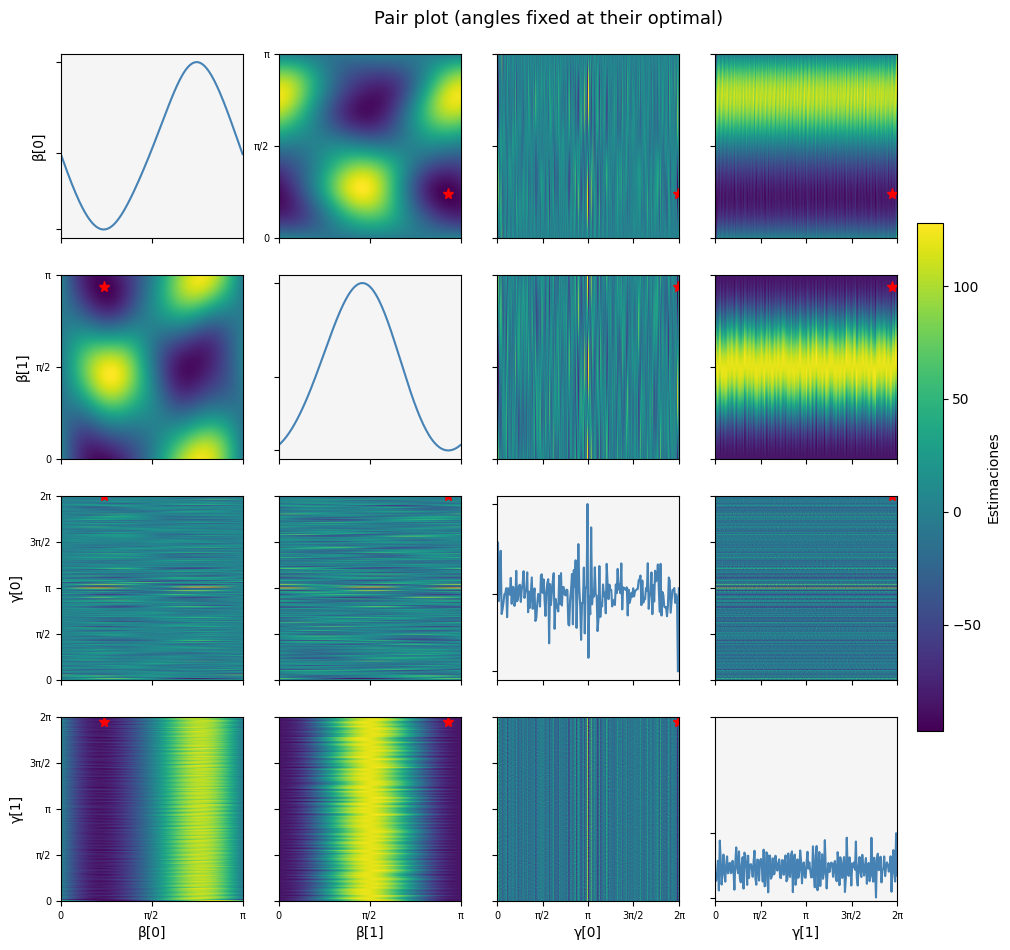

In [59]:
figp2, axesp2 = plt.subplots(4, 4, figsize = (13, 11))

figp2.suptitle("Pair plot (angles fixed at their optimal)", fontsize = 13, y = 0.92)

for i, var_y in enumerate(variables):
    gy = gridsp2[var_y]
    lo_y, hi_y = betabound if i < p else gammabound
    labels_y, ticks_y = beta_ticklabel if i < p else gamma_ticklabel

    for j, var_x in enumerate(variables):
        ax = axesp2[i][j]
        gx = gridsp2[var_x]

        lo_x, hi_x = betabound if j < p else gammabound

        labels_x, ticks_x = beta_ticklabel if j < p else gamma_ticklabel

        if i == j:
            vals = []

            for v in gridsp2[var_y]: 
                args = [fixed[k] % np.pi if k < p else fixed[k] % (2*np.pi) for k in range(4)]
                args[i] = v
                vals.append(qaoa.evaluate_params(circuitp2, Hc, args))

            ax.plot(gridsp2[var_y], vals, color='steelblue', linewidth=1.5)
            ax.set_xlim(lo_y, hi_y)
            ax.set_facecolor("#f5f5f5ff")

            vals_min = min(vals)
            vals_max = max(vals)

            # vals_min_str = str(vals_min)
            # vals_max_str = str(vals_max)
            # diag_ticks = [vals_min, 0, vals_max]
            # diag_tickslabels = [vals_min_str, "0", vals_max_str]

            ax.set_yticks([vals_min, 0, vals_max])
            ax.set_yticklabels([])
            
        else:
            Z = all_Z[(i, j)]

            ax.imshow(Z, origin='lower', aspect='auto', cmap=cmap, 
                      extent=[lo_x, hi_x, lo_y, hi_y])
            
            ax.plot(fixed[j] % np.pi if j < p else fixed[j] % (2*np.pi), fixed[i]% np.pi if i < p else fixed[i]% (2*np.pi), 'r*', markersize=8)

            ax.set_yticks(ticks_y)
            if j == 0 and i > 0:
                ax.set_yticklabels(labels_y, fontsize=7)
            elif j == 1 and i == 0: 
                ax.set_yticklabels(labels_y, fontsize = 7, ha = 'right')
            else:
                ax.set_yticklabels([], fontsize = 7)
        

        

        ax.set_xticks(ticks_x)
        ax.set_xticklabels(labels_x if i == 2*p - 1 else [], fontsize=7)

        

        if i == 2*p - 1:
            ax.set_xlabel(var_x, fontsize=10)
        if j == 0:
            ax.set_ylabel(var_y, fontsize=10)
        



#figp2.subplots_adjust(right=0.88, top=0.90, hspace=0.15, wspace=0.15)

figp2.colorbar(cm.ScalarMappable( norm = normp2, cmap=cmap),
             ax=axesp2, label='Estimaciones', shrink=0.6, pad=0.02)

#plt.tight_layout()

figp2.savefig("figures/5Qubit_PruebasGrid_aumentarCapas_p2.png", dpi=150)

plt.show()
        

### **2. Normalizar el Hamiltoniano**

In [60]:
nHc, _ = qaoa.define_hamiltonian(qubo)
Hc_coeffs = nHc.coeffs
hnorm = np.max(np.abs(Hc_coeffs))
nHc.coeffs = Hc_coeffs / hnorm

print(nHc)

SparsePauliOp(['IIIIZ', 'IIZII', 'ZIIII', 'IIIZI', 'IZIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-0.67+0.j, -0.22+0.j, -0.59+0.j, -0.4 +0.j, -1.  +0.j,  0.14+0.j,
 -0.21+0.j,  0.24+0.j,  0.19+0.j, -0.09+0.j,  0.3 +0.j, -0.18+0.j,
  0.02+0.j, -0.09+0.j,  0.01+0.j])


In [61]:
circuit2 = qaoa.construct_circuit(nHc, reps = 1)

In [62]:
grid = 300

betha_grid = np.linspace(0, np.pi, grid)
gamma_grid = np.linspace(0, 2*np.pi, grid)

B, G = np.meshgrid(betha_grid, gamma_grid)

param_vals = np.column_stack([B.ravel(), G.ravel()])

In [63]:
evals = qaoa.evaluate_params(circuit2, nHc, param_vals)

Z = evals.reshape(grid, grid)

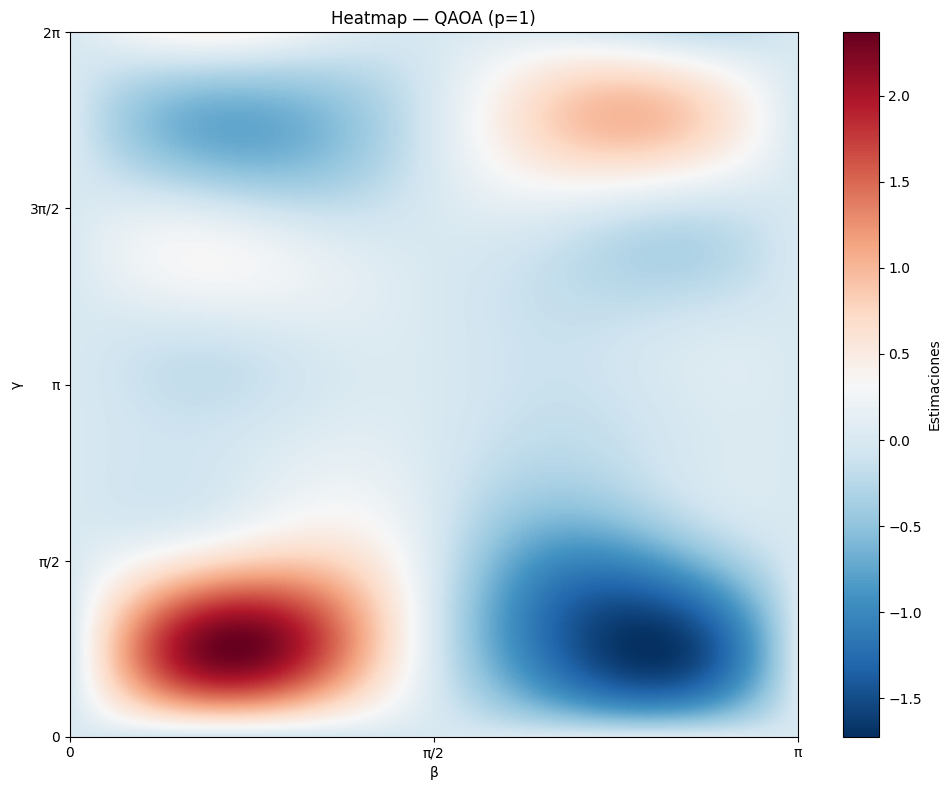

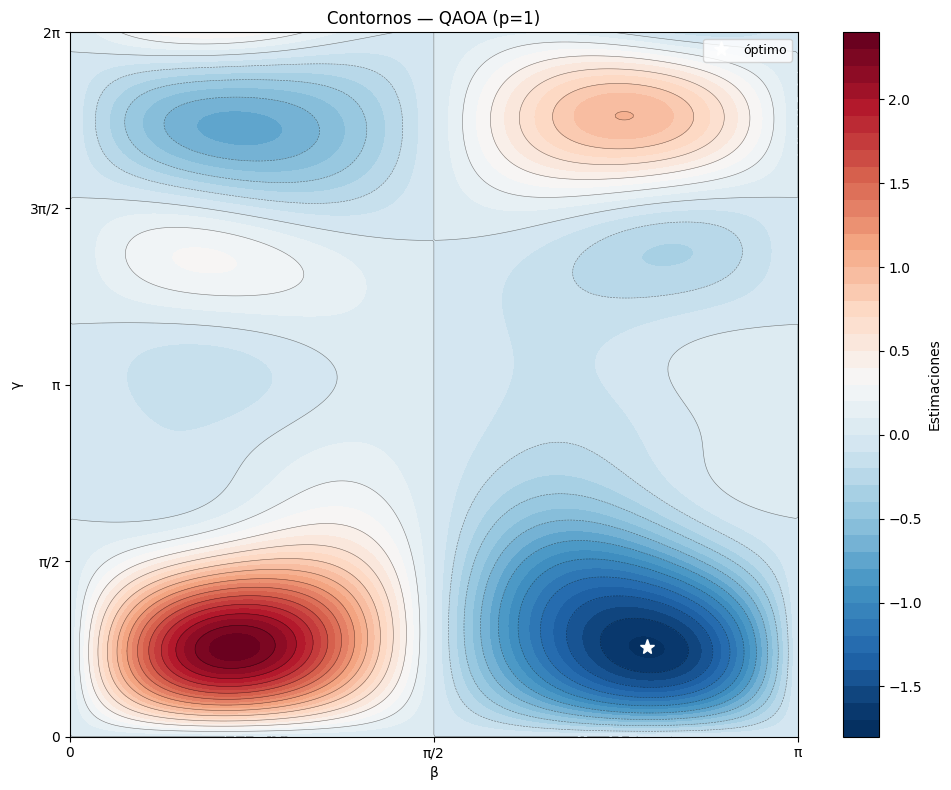

In [64]:
ticks_b = [0, np.pi/2, np.pi]
ticks_g = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

lbls_b = ["0", "π/2", "π"]
lbls_g = ["0", "π/2", "π", "3π/2", "2π"]

def _format_ax(ax):
    ax.set_xticks(ticks_b); ax.set_xticklabels(lbls_b)
    ax.set_yticks(ticks_g); ax.set_yticklabels(lbls_g)
    ax.set_xlabel("β"); ax.set_ylabel("γ")

# — Figura 1: heatmap ───────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 8))
im = ax1.imshow(
    Z, origin="lower", aspect="auto",
    extent=[0, np.pi, 0, 2*np.pi],
    cmap="RdBu_r", vmin = Z.min(), vmax= Z.max()
)
fig1.colorbar(im, ax=ax1, label="Estimaciones")
_format_ax(ax1)
ax1.set_title(f"Heatmap — QAOA (p={1})")
fig1.tight_layout()
fig1.savefig("figures/5Qubit_PruebasGrid_NormalizarHamiltoniano_Heatmap.png", dpi=150)



fig2, ax2 = plt.subplots(figsize=(10, 8))
cf = ax2.contourf(B, G, Z, levels=40, cmap="RdBu_r", vmin=Z.min(), vmax=Z.max())
ax2.contour(B, G, Z, levels=20, colors="k", linewidths=0.4, alpha=0.5)

idx = np.unravel_index(Z.argmin(), Z.shape)
ax2.plot(B[idx], G[idx], "w*", ms=11, label="óptimo")
ax2.legend(fontsize=9)

fig2.colorbar(cf, ax=ax2, label="Estimaciones")
_format_ax(ax2)
ax2.set_title(f"Contornos — QAOA (p={1})")
fig2.tight_layout()
fig2.savefig("figures/5Qubit_PruebasGrid_NormalizarHamiltoniano_Contornos.png", dpi=150)


plt.show()

In [65]:
print(Z.min())

-1.722210621400515


In [66]:
i = np.unravel_index(Z.argmin(), Z.shape)
print(B[i])
print(G[i])

2.490158725420672
0.7985319119492451


In [67]:
_, result = qaoa.qaoa_algorithm(circuit2, nHc)
print(result)

{'β[0]': np.float64(-0.6505153290129466), 'γ[0]': np.float64(0.79474000872587)}


In [68]:
norm_value = qaoa.evaluate_params(circuit2, nHc, result)
print(norm_value * hnorm)    

-86.11208585378564


In [69]:
orCircuit = qaoa.construct_circuit(Hc, reps = 1)
_, orresult = qaoa.qaoa_algorithm(orCircuit, Hc)
print(orresult)

{'β[0]': np.float64(0.6505061267065428), 'γ[0]': np.float64(-0.01589582783491532)}


In [70]:
minimumValue = qaoa.evaluate_params(orCircuit, Hc, orresult)
print(f'MinimumValue = {minimumValue}')

MinimumValue = -86.11208577070312


### **3. Reducir rango de ángulos**

In [71]:
gamma_range = (-np.pi/4, np.pi/4)
beta_range = (-np.pi/4, np.pi/4)

p = 1
circuito = qaoa.construct_circuit(Hc, reps = p)

In [72]:
grid = 300

beta_grid = np.linspace(beta_range[0], beta_range[1], grid)
gamma_grid = np.linspace(gamma_range[0], gamma_range[1], grid)

B, G = np.meshgrid(beta_grid, gamma_grid)

params = np.column_stack([B.ravel(), G.ravel()])


In [73]:
evals = qaoa.evaluate_params(circuito, Hc, params)


Z = evals.reshape(grid, grid)

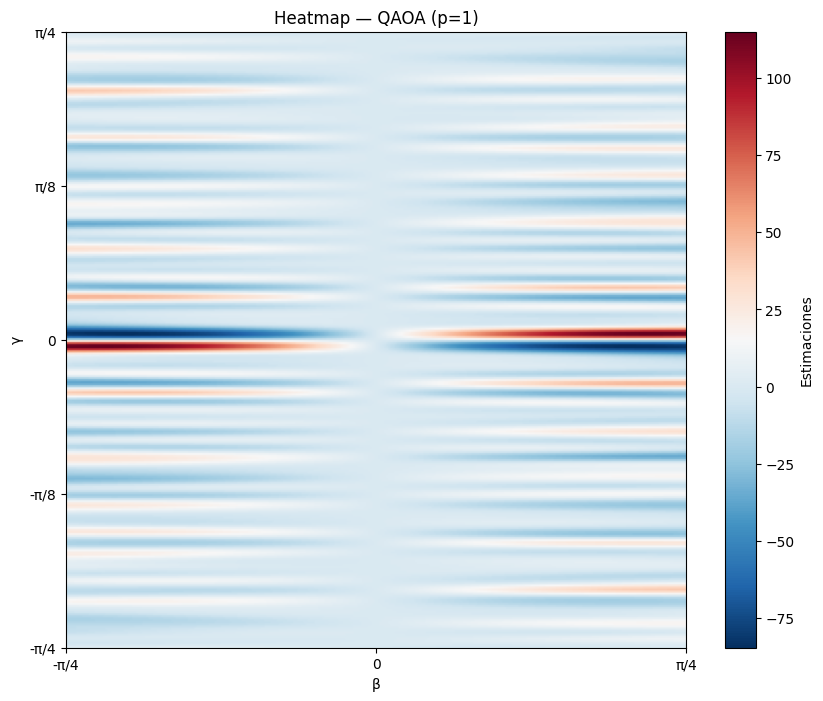

In [74]:
ticks_b = [-np.pi/4, 0, np.pi/4]
ticks_g = [-np.pi/4, -np.pi/8, 0, np.pi/8, np.pi/4]

lbls_b = ["-π/4", "0", "π/4"]
lbls_g = ["-π/4", "-π/8", "0", "π/8", "π/4"]

def _format_ax(ax):
    ax.set_xticks(ticks_b); ax.set_xticklabels(lbls_b)
    ax.set_yticks(ticks_g); ax.set_yticklabels(lbls_g)
    ax.set_xlabel("β"); ax.set_ylabel("γ")

# — Figura 1: heatmap ───────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 8))
im = ax1.imshow(
    Z, origin="lower", aspect="auto",
    extent=[-np.pi/4, np.pi/4, -np.pi/4, np.pi/4],
    cmap="RdBu_r", vmin=Z.min(), vmax=Z.max()
)
fig1.colorbar(im, ax=ax1, label="Estimaciones")
_format_ax(ax1)
ax1.set_title(f"Heatmap — QAOA (p={1})")
#fig1.tight_layout()
fig1.savefig("figures/5Qubit_PruebasGrid_ReducirLimites.png", dpi=150)


plt.show()